In [1]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx


In [2]:
place = "Gila River Indian Community, Arizona, USA"

# Get boundary
boundary = ox.geocode_to_gdf(place)

# Get roads from OpenStreetMap
G = ox.graph_from_place(place, network_type="drive")
roads = ox.graph_to_gdfs(G, nodes=False, edges=True)


In [3]:
# Get water / river features
tags = {
    "waterway": True,
    "natural": ["water", "wetland"],
    "landuse": True
}
features = ox.features_from_polygon(boundary.geometry.iloc[0], tags)

# Project to Web Mercator for basemap
boundary = boundary.to_crs(epsg=3857)
roads = roads.to_crs(epsg=3857)
features = features.to_crs(epsg=3857)


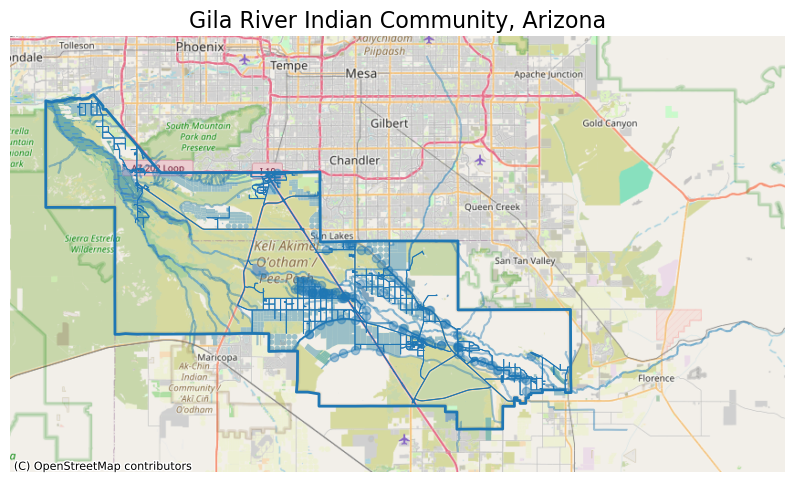

In [4]:
# Plot
fig, ax = plt.subplots(figsize=(10, 10))

boundary.boundary.plot(ax=ax, linewidth=2)
roads.plot(ax=ax, linewidth=0.7)
features.plot(ax=ax, alpha=0.4)

ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_title("Gila River Indian Community, Arizona", fontsize=16)
ax.axis("off")

plt.show()

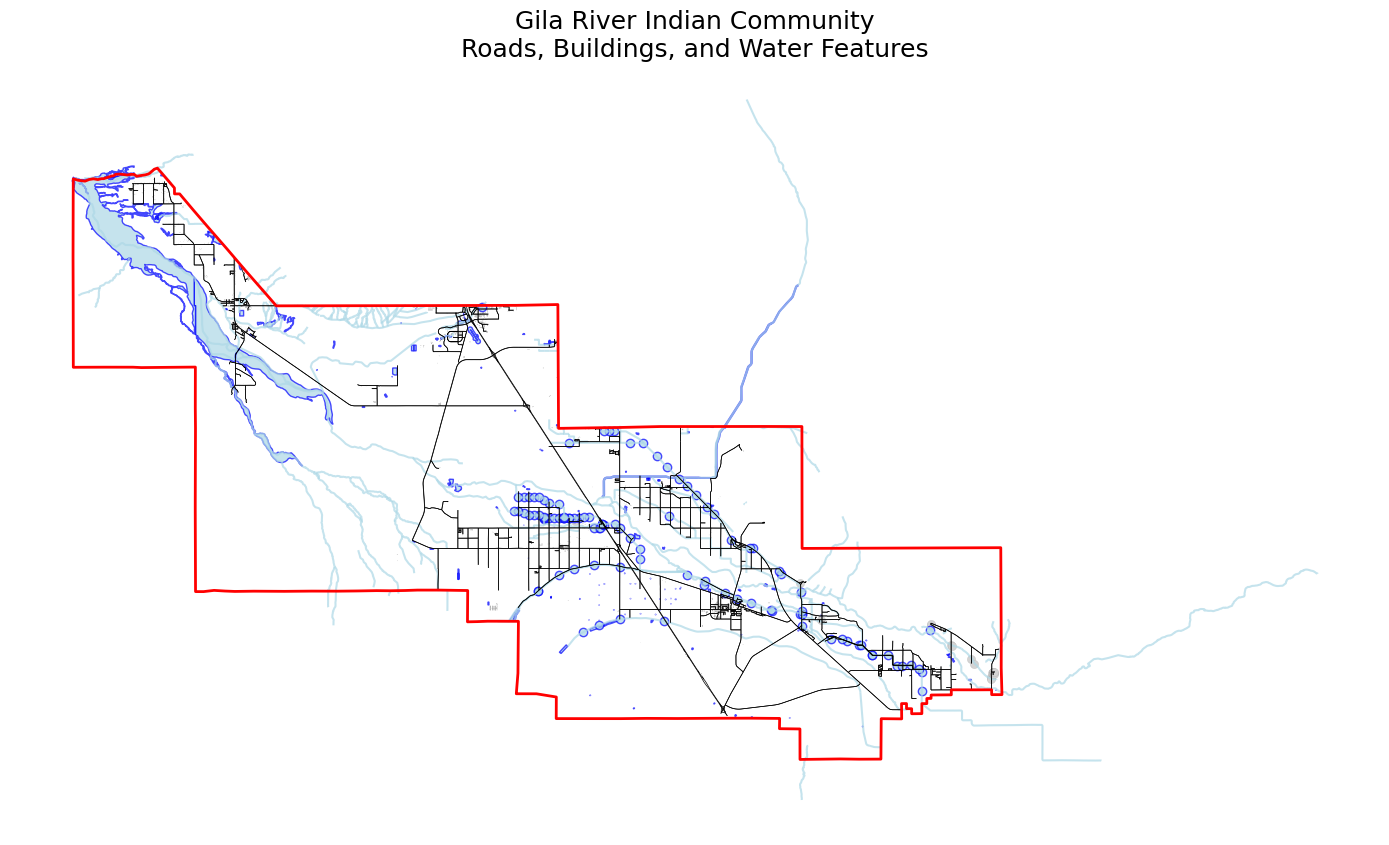

In [5]:

# --------------------------------------------------
# Gila River Indian Community Boundary
# --------------------------------------------------
place = "Gila River Indian Community, Arizona, USA"

boundary = ox.geocode_to_gdf(place)
polygon = boundary.geometry.iloc[0]

# --------------------------------------------------
# Roads
# --------------------------------------------------
G = ox.graph_from_polygon(polygon, network_type="drive")
roads = ox.graph_to_gdfs(G, nodes=False)

# --------------------------------------------------
# Buildings
# --------------------------------------------------
buildings = ox.features_from_polygon(
    polygon,
    tags={"building": True}
)

# --------------------------------------------------
# Water Features
# --------------------------------------------------
water = ox.features_from_polygon(
    polygon,
    tags={
        "natural": ["water", "wetland"],
        "waterway": True
    }
)

# --------------------------------------------------
# Reproject
# --------------------------------------------------
boundary = boundary.to_crs(epsg=3857)
roads = roads.to_crs(epsg=3857)
buildings = buildings.to_crs(epsg=3857)
water = water.to_crs(epsg=3857)

# --------------------------------------------------
# Plot
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(14,14))

# Buildings
buildings.plot(
    ax=ax,
    color="lightgray",
    edgecolor="gray",
    linewidth=0.1
)

# Water
water.plot(
    ax=ax,
    color="lightblue",
    edgecolor="blue",
    alpha=0.7
)

# Roads
roads.plot(
    ax=ax,
    color="black",
    linewidth=0.5
)

# Boundary
boundary.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2
)

ax.set_title(
    "Gila River Indian Community\nRoads, Buildings, and Water Features",
    fontsize=18
)

ax.axis("off")
plt.tight_layout()
plt.show()

In [7]:
gila_boundary = boundary.to_crs(epsg=4326)
gila_boundary

,geometry,bbox_west,bbox_south,bbox_east,bbox_north,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"POLYGON ((-112.30629 33.32529, -112.30617 33.2...",-112.306291,32.967088,-111.515615,33.388326,332995353,relation,10731873,33.177729,-111.944008,boundary,aboriginal_lands,25,0.066717,aboriginal_lands,Gila River Indian Community,"Gila River Indian Community, Pinal County, Ari..."


<Axes: >

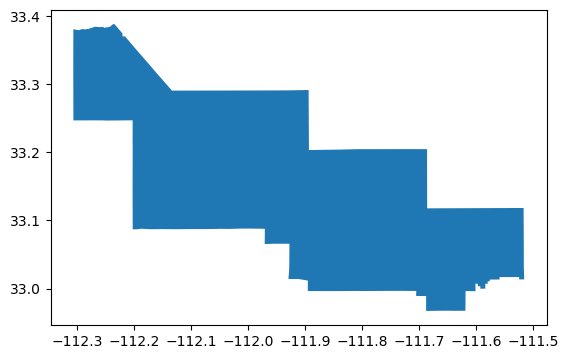

In [8]:
gila_boundary.plot()

In [9]:
%store gila_boundary

Stored 'gila_boundary' (GeoDataFrame)
